# 04. Inverse Probability Weighting

Regression adjustment models the outcome. Propensity scores model treatment assignment. Matching uses the propensity score or covariates to construct a comparison set.

Inverse probability weighting, often shortened to IPW or IPTW, takes a different route:

> Reweight the observed data so the weighted sample behaves more like a randomized experiment on observed covariates.

The intuition is simple. If a treated unit had only a small probability of being treated, that unit represents many similar units who could have been treated but were not. If an untreated unit had only a small probability of remaining untreated, that unit represents many similar units who could have remained untreated but were treated.

The weights are inverse probabilities because rare treatment assignments receive larger weights.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain inverse probability weighting as a pseudo-population design.
- Derive ATE, ATT, and stabilized weights from the propensity score.
- Distinguish Horvitz-Thompson and Hájek style weighted estimators.
- Fit a propensity-score model and construct IPW estimates in Python.
- Diagnose weight distributions, effective sample size, and covariate balance.
- Explain why positivity violations create extreme weights.
- Understand why trimming or capping weights changes the analysis and must be reported.
- Translate IPW results into an industry-facing causal readout.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit
from sklearn.metrics import roc_auc_score
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 3)

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz DAG with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans", fontsize="11", margin="0.12,0.08", color="#334155")
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def weighted_mean_and_var(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """Compute standardized mean differences, optionally after weighting."""
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def plot_smd_comparison(balance_tables, title, threshold=0.10):
    plot_df = pd.concat(
        [table.assign(source=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    fig, ax = plt.subplots(figsize=(8.8, max(4.2, 0.36 * len(order))))
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="covariate",
        hue="source",
        style="source",
        s=75,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def fit_propensity_model(formula, data, label, clip=0.01):
    model = smf.logit(formula, data=data).fit(disp=False, maxiter=250)
    score = np.clip(model.predict(data), clip, 1 - clip)
    return {"label": label, "formula": formula, "model": model, "score": score}


def ate_weights(treatment, score):
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    return treatment / score + (1 - treatment) / (1 - score)


def stabilized_ate_weights(treatment, score):
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    p_treated = treatment.mean()
    return treatment * p_treated / score + (1 - treatment) * (1 - p_treated) / (1 - score)


def att_weights(treatment, score):
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    return treatment + (1 - treatment) * score / (1 - score)


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.sum(weights ** 2)


def weighted_difference(outcome, treatment, weights):
    outcome = np.asarray(outcome, dtype=float)
    treatment = np.asarray(treatment, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mu1 = np.sum(weights * treatment * outcome) / np.sum(weights * treatment)
    mu0 = np.sum(weights * (1 - treatment) * outcome) / np.sum(weights * (1 - treatment))
    return mu1 - mu0


def ipw_estimators(outcome, treatment, score):
    outcome = np.asarray(outcome, dtype=float)
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    ht = np.mean(treatment * outcome / score - (1 - treatment) * outcome / (1 - score))
    wt_treated = treatment / score
    wt_control = (1 - treatment) / (1 - score)
    hajek = np.sum(wt_treated * outcome) / np.sum(wt_treated) - np.sum(wt_control * outcome) / np.sum(wt_control)
    return ht, hajek


def summarize_weights(weights, label):
    weights = np.asarray(weights, dtype=float)
    return {
        "weights": label,
        "mean": weights.mean(),
        "std": weights.std(ddof=1),
        "min": weights.min(),
        "p50": np.quantile(weights, 0.50),
        "p90": np.quantile(weights, 0.90),
        "p95": np.quantile(weights, 0.95),
        "p99": np.quantile(weights, 0.99),
        "max": weights.max(),
        "effective_sample_size": effective_sample_size(weights),
        "ess_share_of_n": effective_sample_size(weights) / len(weights),
        "share_above_10": np.mean(weights > 10),
        "share_above_25": np.mean(weights > 25),
    }

## 1. The Core Idea

In an observational study, treated and untreated units may have different covariate distributions. IPW tries to build a weighted pseudo-population where the distribution of observed covariates is similar across treatment groups.

For ATE estimation, the basic weights are:

$$
w_i^{ATE} = \frac{D_i}{e(X_i)} + \frac{1-D_i}{1-e(X_i)}
$$

where:

$$
e(X_i) = P(D_i=1 \mid X_i)
$$

A treated unit receives weight `1 / e(X_i)`. A control unit receives weight `1 / (1 - e(X_i))`.

Horvitz and Thompson (1952) developed inverse probability ideas in survey sampling. Robins, Hernán, and Brumback (2000) brought inverse probability weighting into marginal structural models for causal inference, especially for time-varying treatment settings. Cole and Hernán (2008) give practical guidance on constructing inverse probability weights.

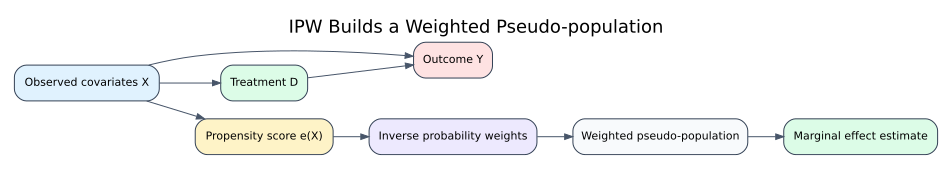

In [3]:
weighting_edges = [
    ("Observed covariates X", "Treatment D"),
    ("Observed covariates X", "Outcome Y"),
    ("Treatment D", "Outcome Y"),
    ("Observed covariates X", "Propensity score e(X)"),
    ("Propensity score e(X)", "Inverse probability weights"),
    ("Inverse probability weights", "Weighted pseudo-population"),
    ("Weighted pseudo-population", "Marginal effect estimate"),
]

weighting_colors = {
    "Observed covariates X": "#e0f2fe",
    "Treatment D": "#dcfce7",
    "Outcome Y": "#fee2e2",
    "Propensity score e(X)": "#fef3c7",
    "Inverse probability weights": "#ede9fe",
    "Weighted pseudo-population": "#f8fafc",
    "Marginal effect estimate": "#dcfce7",
}

display(make_dag(weighting_edges, "IPW Builds a Weighted Pseudo-population", weighting_colors))

### Interpretation

The weighting step is a design step. It uses treatment assignment and pre-treatment covariates to create a weighted comparison. After weighting, a simple marginal comparison of outcomes can estimate a causal effect if the assumptions hold.

This is why IPW is often described as fitting a marginal structural model. The outcome model can be simple because the weights are intended to remove observed confounding.

## 2. Identification Assumptions

For point-treatment IPW, the familiar assumptions appear again.

### Consistency

The observed outcome equals the potential outcome under the treatment actually received:

$$
Y_i = D_iY_i(1) + (1-D_i)Y_i(0)
$$

### Conditional Exchangeability

After conditioning on observed pre-treatment covariates, treatment assignment is independent of potential outcomes:

$$
(Y_i(1), Y_i(0)) \perp D_i \mid X_i
$$

### Positivity

Each covariate profile in the target population has positive probability of each treatment condition:

$$
0 < P(D_i=1 \mid X_i=x) < 1
$$

### Correct Enough Weight Model

The propensity-score model must estimate the relevant treatment probabilities well enough for the target estimand. Cole and Hernán (2008) emphasize that weighting requires thoughtful covariate selection, positivity assessment, and model specification.

## 3. Running Example: Customer-Success Outreach

We continue with the customer-success outreach example.

A SaaS company gives proactive outreach to selected accounts. The intervention is targeted toward high-risk accounts and influenced by customer-success capacity. We want the average effect of outreach on next-quarter account health.

This time, we will estimate the ATE by weighting accounts into a pseudo-population where contacted and uncontacted accounts are balanced on observed baseline covariates.

In [4]:
def simulate_customer_success(n=9000, seed=4044):
    rng = np.random.default_rng(seed)

    plan = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    plan_effect = pd.Series(plan).map({"startup": 0.0, "growth": 3.0, "enterprise": 7.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.0, size=n), 1, 48)
    usage = np.clip(rng.normal(50 + 0.6 * tenure + 2.0 * plan_effect, 12, n), 5, 120)
    pre_value = np.clip(rng.normal(80 + 1.2 * tenure + 5.0 * plan_effect, 18, n), 20, 220)
    risk_score = expit(1.4 - 0.045 * usage - 0.012 * pre_value + rng.normal(0, 0.8, n))
    manager_capacity = rng.normal(0, 1, n)

    treatment_probability = expit(
        -2.15
        + 4.1 * risk_score
        + 0.45 * (plan == "enterprise")
        + 0.25 * (plan == "growth")
        - 0.008 * tenure
        + 0.85 * manager_capacity
    )
    treated = rng.binomial(1, treatment_probability)

    y0 = (
        62
        + 0.10 * pre_value
        + 0.18 * tenure
        + 0.22 * usage
        + plan_effect
        - 22 * risk_score
        + 8 * risk_score**2
        + rng.normal(0, 4.5, n)
    )

    individual_effect = (
        3.0
        + 1.00 * (plan == "enterprise")
        + 0.45 * (plan == "growth")
        - 1.40 * risk_score
        + 0.012 * usage
    )

    outcome = y0 + individual_effect * treated

    return pd.DataFrame({
        "plan": plan,
        "tenure": tenure,
        "usage": usage,
        "pre_value": pre_value,
        "risk_score": risk_score,
        "manager_capacity": manager_capacity,
        "true_assignment_probability": treatment_probability,
        "treated": treated,
        "y0": y0,
        "true_individual_effect": individual_effect,
        "outcome": outcome,
    })


df = simulate_customer_success()
true_ate = df["true_individual_effect"].mean()
true_att = df.loc[df["treated"] == 1, "true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in simulation",
        "True ATT among contacted accounts",
        "Naive treated-control difference",
        "Naive bias vs true ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        true_att,
        naive_effect,
        naive_effect - true_ate,
    ],
})

display(summary)
display(df.head())

,quantity,value
0,Number of accounts,9000.000
1,Share receiving outreach,0.180
2,True ATE in simulation,4.025
3,True ATT among contacted accounts,4.000
4,Naive treated-control difference,3.024
5,Naive bias vs true ATE,-1.001


,plan,tenure,usage,pre_value,risk_score,manager_capacity,true_assignment_probability,treated,y0,true_individual_effect,outcome
0,growth,23.023,62.467,127.724,0.058,1.484,0.357,0,88.916,4.119,88.916
1,enterprise,18.656,90.407,149.252,0.037,0.456,0.212,0,100.661,5.033,100.661
2,growth,13.814,62.982,99.308,0.032,0.260,0.160,1,92.886,4.161,97.047
3,startup,10.978,57.028,115.328,0.111,0.382,0.189,1,89.688,3.529,93.217
4,growth,15.351,66.397,123.517,0.040,0.391,0.178,0,101.729,4.191,101.729


### Interpretation

The naive comparison is biased because outreach was targeted. In a real project, we would not know the true ATE. The simulation lets us see whether the estimator moves in the right direction under known data-generating conditions.

Our goal is to recover the population-level average effect, not only the effect among contacted accounts.

## 4. Raw Imbalance Before Weighting

Before constructing weights, inspect whether treatment groups differ on baseline variables.

,covariate,treated_mean,control_mean,smd,abs_smd
4,manager_capacity,0.622,-0.133,0.788,0.788
0,risk_score,0.106,0.082,0.248,0.248
3,tenure,14.323,15.786,-0.148,0.148
1,usage,62.901,64.695,-0.123,0.123
7,plan_startup,0.387,0.423,-0.073,0.073
2,pre_value,109.940,111.480,-0.061,0.061
6,plan_growth,0.400,0.380,0.040,0.040
5,plan_enterprise,0.213,0.197,0.040,0.040


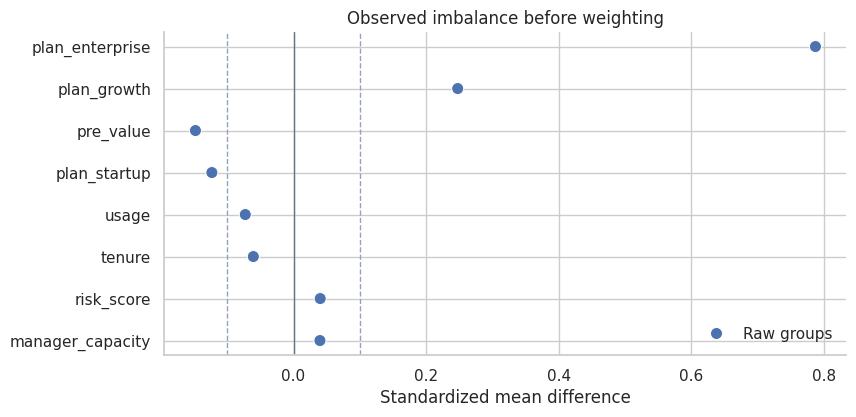

In [5]:
plan_dummies = pd.get_dummies(df["plan"], prefix="plan", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "usage", "pre_value", "tenure", "manager_capacity"]], plan_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]
confounder_covariates = [c for c in balance_covariates if c != "manager_capacity"]

raw_balance = standardized_mean_differences(balance_frame, balance_covariates)
display(raw_balance)

plot_smd_comparison(
    {"Raw groups": raw_balance},
    title="Observed imbalance before weighting",
)

### Interpretation

Several baseline covariates differ between contacted and uncontacted accounts. This is the imbalance IPW will try to remove.

`manager_capacity` is included because it strongly affects treatment assignment. In this simulation it does not affect potential outcomes, so it is assignment-relevant but not a confounder. This helps illustrate why treatment prediction and causal precision are not always the same objective.

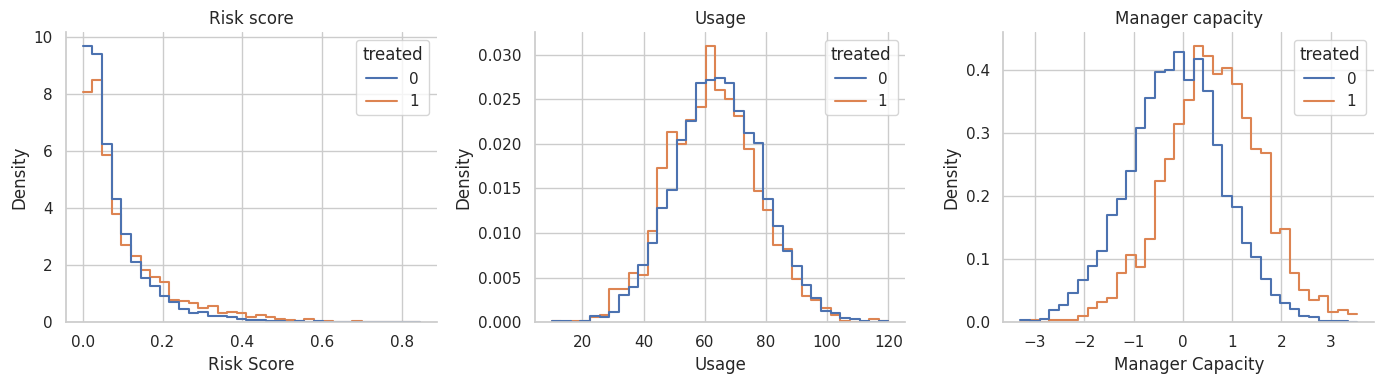

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in [
    (axes[0], "risk_score", "Risk score"),
    (axes[1], "usage", "Usage"),
    (axes[2], "manager_capacity", "Manager capacity"),
]:
    sns.histplot(
        data=df,
        x=col,
        hue="treated",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " ").title())
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

Risk and usage differ by treatment status, and those variables also affect account health. This creates confounding.

Manager capacity differs strongly because it affected whether an account got outreach. If it does not affect account health, including it can improve treatment prediction while also creating more extreme weights. That is a useful finite-sample warning.

## 5. Fit Propensity-Score Models

We will compare three score models:

1. **Underspecified score**: leaves out important confounders.
2. **Confounder score**: includes the main customer-health confounders.
3. **Assignment-heavy score**: also includes manager capacity, a strong treatment predictor that does not affect potential outcomes in the simulation.

The point is not that one formula is universally right. The point is to see how model choices affect balance, weights, effective sample size, and estimated effects.

In [7]:
score_models = [
    fit_propensity_model(
        "treated ~ pre_value + tenure + C(plan)",
        df,
        "Underspecified score",
    ),
    fit_propensity_model(
        "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
        df,
        "Confounder score",
    ),
    fit_propensity_model(
        "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan) + manager_capacity",
        df,
        "Assignment-heavy score",
    ),
]

for item in score_models:
    df[item["label"]] = item["score"]

score_diagnostics = []
for item in score_models:
    score = item["score"]
    weights = ate_weights(df["treated"], score)
    ht, hajek = ipw_estimators(df["outcome"], df["treated"], score)
    score_diagnostics.append({
        "score_model": item["label"],
        "auc_for_treatment_prediction": roc_auc_score(df["treated"], score),
        "min_score": score.min(),
        "median_score": np.median(score),
        "p99_score": np.quantile(score, 0.99),
        "max_score": score.max(),
        "ipw_horvitz_thompson": ht,
        "ipw_hajek_normalized": hajek,
        "hajek_bias_vs_true_ate": hajek - true_ate,
        "weight_ess": effective_sample_size(weights),
        "max_weight": weights.max(),
    })

score_diagnostics = pd.DataFrame(score_diagnostics)
display(score_diagnostics)

,score_model,auc_for_treatment_prediction,min_score,median_score,p99_score,max_score,ipw_horvitz_thompson,ipw_hajek_normalized,hajek_bias_vs_true_ate,weight_ess,max_weight
0,Underspecified score,0.550,0.097,0.182,0.225,0.245,3.516,3.472,-0.553,5224.189,10.323
1,Confounder score,0.577,0.103,0.173,0.355,0.678,4.165,4.168,0.143,5097.121,9.649
2,Assignment-heavy score,0.728,0.010,0.147,0.615,0.880,5.672,4.008,-0.017,3063.937,83.303


### Interpretation

The underspecified score has weak treatment prediction and leaves confounding unaddressed. The confounder score improves the causal estimate by weighting on the variables responsible for outcome-related selection. The assignment-heavy score has much higher treatment-prediction AUC, but it also produces larger weights and a lower effective sample size.

For IPW, a high AUC is not automatically good news. A score that nearly separates treated and untreated units can create unstable weights.

## 6. ATE Weights and the Pseudo-population

For ATE estimation, treated units get weight `1 / e(X)`, and controls get weight `1 / (1 - e(X))`.

The normalized, or Hájek, weighted estimator is:

$$
\widehat{E}[Y(1)] = \frac{\sum_i D_iY_i/e_i}{\sum_i D_i/e_i}
$$

$$
\widehat{E}[Y(0)] = \frac{\sum_i (1-D_i)Y_i/(1-e_i)}{\sum_i (1-D_i)/(1-e_i)}
$$

$$
\widehat{ATE}_{IPW} = \widehat{E}[Y(1)] - \widehat{E}[Y(0)]
$$

The Horvitz-Thompson version does not normalize within treatment groups. It can be unbiased under ideal conditions, but it can be more sensitive to extreme weights in finite samples.

In [8]:
selected_score = df["Confounder score"].to_numpy()
df["ate_weight"] = ate_weights(df["treated"], selected_score)
df["stabilized_ate_weight"] = stabilized_ate_weights(df["treated"], selected_score)

pseudo_population = pd.DataFrame({
    "quantity": [
        "Raw treated count",
        "Raw control count",
        "Sum of unstabilized weights among treated",
        "Sum of unstabilized weights among controls",
        "Sum of stabilized weights among treated",
        "Sum of stabilized weights among controls",
        "Total raw sample size",
        "Total unstabilized pseudo-population size",
        "Total stabilized weighted size",
    ],
    "value": [
        (df["treated"] == 1).sum(),
        (df["treated"] == 0).sum(),
        df.loc[df["treated"] == 1, "ate_weight"].sum(),
        df.loc[df["treated"] == 0, "ate_weight"].sum(),
        df.loc[df["treated"] == 1, "stabilized_ate_weight"].sum(),
        df.loc[df["treated"] == 0, "stabilized_ate_weight"].sum(),
        len(df),
        df["ate_weight"].sum(),
        df["stabilized_ate_weight"].sum(),
    ],
})

display(pseudo_population)

,quantity,value
0,Raw treated count,1623.000
1,Raw control count,7377.000
2,Sum of unstabilized weights among treated,9000.409
3,Sum of unstabilized weights among controls,9000.700
4,Sum of stabilized weights among treated,1623.074
5,Sum of stabilized weights among controls,7377.574
6,Total raw sample size,9000.000
7,Total unstabilized pseudo-population size,18001.109
8,Total stabilized weighted size,9000.647


### Interpretation

Unstabilized ATE weights create a pseudo-population where each treatment condition is expanded to roughly the full original population size. Stabilized weights rescale the weights so the total weighted sample size remains closer to the original sample size.

The point estimate from a weighted mean comparison is often unchanged by stabilization because all treated weights and all control weights are multiplied by treatment-group constants. The variance behavior and diagnostics are easier to interpret with stabilized weights.

## 7. Weight Diagnostics

Weight diagnostics are not optional. Extreme weights are evidence of weak overlap, score-model problems, or an estimand that the data cannot support well.

A useful first pass includes:

- Mean and maximum weights.
- 95th and 99th percentiles.
- Effective sample size.
- Share of units above practical thresholds.
- Weight distributions by treatment group.

In [9]:
weight_tables = []
for item in score_models:
    score = item["score"]
    weight_tables.append(summarize_weights(ate_weights(df["treated"], score), f"ATE - {item['label']}"))
    weight_tables.append(summarize_weights(stabilized_ate_weights(df["treated"], score), f"Stabilized ATE - {item['label']}"))

weight_diagnostics = pd.DataFrame(weight_tables)
display(weight_diagnostics)

,weights,mean,std,min,p50,p90,p95,p99,max,effective_sample_size,ess_share_of_n,share_above_10,share_above_25
0,ATE - Underspecified score,2.000,1.701,1.111,1.232,5.263,5.860,7.048,10.323,5224.189,0.580,1.111e-04,0.000
1,Stabilized ATE - Underspecified score,1.000,0.069,0.736,0.999,1.045,1.064,1.271,1.862,8957.755,0.995,0.000e+00,0.000
2,ATE - Confounder score,2.000,1.750,1.115,1.219,5.442,6.199,7.554,9.649,5097.121,0.566,0.000e+00,0.000
3,Stabilized ATE - Confounder score,1.000,0.114,0.272,0.990,1.095,1.185,1.398,2.548,8883.758,0.987,0.000e+00,0.000
4,ATE - Assignment-heavy score,2.017,2.808,1.010,1.193,3.840,6.283,14.080,83.303,3063.937,0.340,2.011e-02,0.002
5,Stabilized ATE - Assignment-heavy score,1.003,0.440,0.205,0.938,1.257,1.479,2.710,15.022,7548.197,0.839,3.333e-04,0.000


### Interpretation

The assignment-heavy score produces much larger weights and a lower effective sample size. This is the finite-sample cost of making treatment assignment highly predictable.

Effective sample size is a useful shorthand:

$$
ESS = \frac{(\sum_i w_i)^2}{\sum_i w_i^2}
$$

When weights are highly unequal, the effective sample size can be far smaller than the nominal row count.

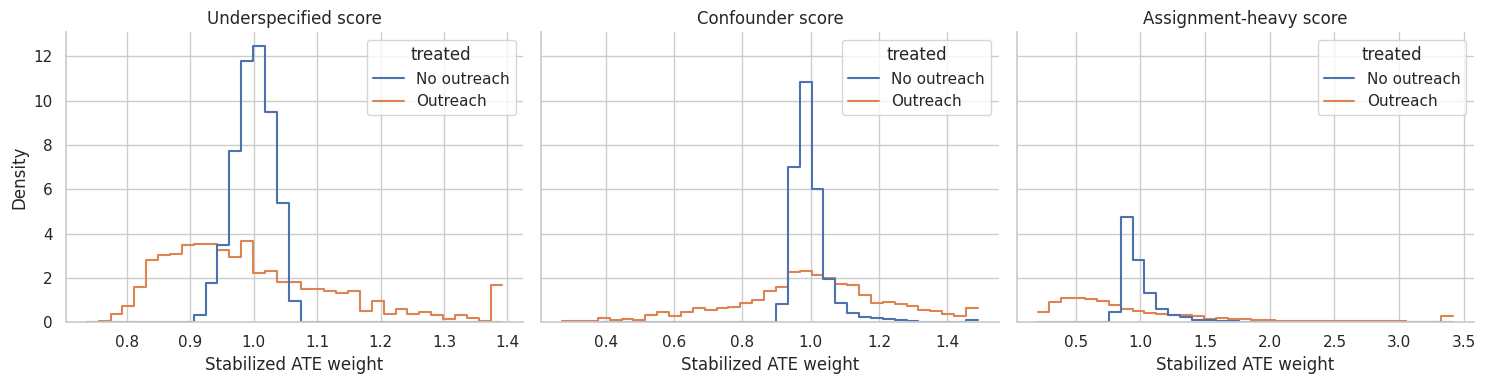

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, item in zip(axes, score_models):
    weights = stabilized_ate_weights(df["treated"], item["score"])
    plot_df = pd.DataFrame({
        "weight": np.minimum(weights, np.quantile(weights, 0.995)),
        "treated": df["treated"].map({0: "No outreach", 1: "Outreach"}),
    })
    sns.histplot(
        data=plot_df,
        x="weight",
        hue="treated",
        bins=35,
        element="step",
        fill=False,
        common_norm=False,
        stat="density",
        ax=ax,
    )
    ax.set_title(item["label"])
    ax.set_xlabel("Stabilized ATE weight")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Interpretation

The stabilized weights for the assignment-heavy score have a longer right tail. A few units receive much more influence than most others.

In a production analysis, those units should be inspected. They often correspond to accounts whose treatment status was surprising given their observed covariates.

## 8. Does Weighting Balance Covariates?

The most important design diagnostic is whether weighting balances the covariates used to justify exchangeability.

Li, Morgan, and Zaslavsky (2017) emphasize covariate balance as central to propensity-score weighting. Lunceford and Davidian (2004) compare propensity-score stratification and weighting for causal treatment-effect estimation.

,design,max_abs_smd_all_variables,mean_abs_smd_all_variables,max_abs_smd_confounders_only,mean_abs_smd_confounders_only
0,Raw groups,0.788,0.190,0.248,0.105
1,Underspecified score,0.790,0.138,0.216,0.045
2,Confounder score,0.792,0.101,0.005,0.002
3,Assignment-heavy score,0.048,0.023,0.048,0.020


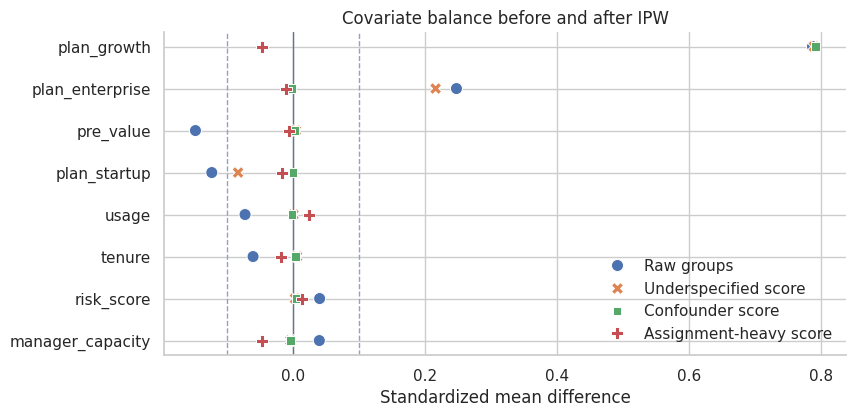

In [11]:
balance_tables = {"Raw groups": raw_balance}
for item in score_models:
    weights = stabilized_ate_weights(df["treated"], item["score"])
    balance_tables[item["label"]] = standardized_mean_differences(balance_frame, balance_covariates, weights=weights)

balance_summary = []
for label, table in balance_tables.items():
    balance_summary.append({
        "design": label,
        "max_abs_smd_all_variables": table["abs_smd"].max(),
        "mean_abs_smd_all_variables": table["abs_smd"].mean(),
        "max_abs_smd_confounders_only": table.query("covariate != 'manager_capacity'")["abs_smd"].max(),
        "mean_abs_smd_confounders_only": table.query("covariate != 'manager_capacity'")["abs_smd"].mean(),
    })

balance_summary = pd.DataFrame(balance_summary)
display(balance_summary)

plot_smd_comparison(
    {
        "Raw groups": balance_tables["Raw groups"],
        "Underspecified score": balance_tables["Underspecified score"],
        "Confounder score": balance_tables["Confounder score"],
        "Assignment-heavy score": balance_tables["Assignment-heavy score"],
    },
    title="Covariate balance before and after IPW",
)

### Interpretation

The underspecified score does not balance important confounders. The confounder score balances the customer-health covariates well. The assignment-heavy score balances more of the assignment process, including manager capacity, but with more variable weights.

The lesson is not to ignore treatment predictors. The lesson is to evaluate the design by balance, overlap, and stability rather than by treatment-prediction AUC alone.

## 9. Weighted Outcome Analysis

Once the weighted design is acceptable, the outcome model can be simple. For a point treatment and ATE, a weighted marginal model is:

$$
E[Y^d] = \beta_0 + \beta_1 d
$$

The coefficient `beta_1` is the marginal treatment effect in the weighted pseudo-population.

Here we compare several estimators.

In [12]:
estimate_rows = [
    {
        "analysis": "Naive difference",
        "horvitz_thompson": np.nan,
        "hajek_or_weighted_difference": naive_effect,
        "wls_treatment_coef": smf.ols("outcome ~ treated", data=df).fit(cov_type="HC3").params["treated"],
    }
]

for item in score_models:
    score = item["score"]
    ht, hajek = ipw_estimators(df["outcome"], df["treated"], score)
    stable_weights = stabilized_ate_weights(df["treated"], score)
    wls = smf.wls("outcome ~ treated", data=df, weights=stable_weights).fit(cov_type="HC3")
    estimate_rows.append({
        "analysis": item["label"],
        "horvitz_thompson": ht,
        "hajek_or_weighted_difference": hajek,
        "wls_treatment_coef": wls.params["treated"],
        "wls_robust_se_teaching_approx": wls.bse["treated"],
        "effective_sample_size": effective_sample_size(stable_weights),
    })

estimate_table = pd.DataFrame(estimate_rows)
estimate_table["true_ate"] = true_ate
estimate_table["bias_of_hajek_vs_true_ate"] = estimate_table["hajek_or_weighted_difference"] - true_ate
display(estimate_table)

,analysis,horvitz_thompson,hajek_or_weighted_difference,wls_treatment_coef,wls_robust_se_teaching_approx,effective_sample_size,true_ate,bias_of_hajek_vs_true_ate
0,Naive difference,NaN,3.024,3.024,NaN,NaN,4.025,-1.001
1,Underspecified score,3.516,3.472,3.472,0.290,8957.755,4.025,-0.553
2,Confounder score,4.165,4.168,4.168,0.274,8883.758,4.025,0.143
3,Assignment-heavy score,5.672,4.008,4.008,0.328,7548.197,4.025,-0.017


### Interpretation

The underspecified score remains biased because the weights do not balance key confounders. The confounder score moves the estimate close to the true ATE. The assignment-heavy score shows a classic IPW issue: the normalized Hájek estimate is stable, while the unnormalized Horvitz-Thompson estimate is much more sensitive to large weights.

The robust standard errors here are teaching approximations. In production, uncertainty should account for estimated weights, clustering if present, and the full design procedure. Bootstrap or specialized sandwich estimators are common options.

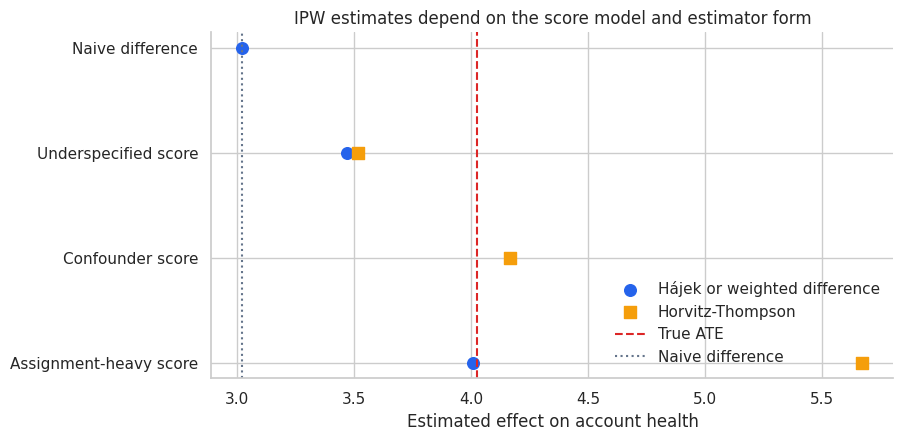

In [13]:
fig, ax = plt.subplots(figsize=(8.8, 4.5))
plot_df = estimate_table.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))
ax.scatter(plot_df["hajek_or_weighted_difference"], y, color="#2563eb", s=70, label="Hájek or weighted difference")
ax.scatter(plot_df["horvitz_thompson"], y, color="#f59e0b", marker="s", s=65, label="Horvitz-Thompson")
ax.axvline(true_ate, color="#dc2626", linestyle="--", linewidth=1.5, label="True ATE")
ax.axvline(naive_effect, color="#64748b", linestyle=":", linewidth=1.5, label="Naive difference")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["analysis"])
ax.set_xlabel("Estimated effect on account health")
ax.set_title("IPW estimates depend on the score model and estimator form")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.show()

### Interpretation

This plot makes the estimator tradeoff visible. The unnormalized Horvitz-Thompson estimate can be pulled by a small number of high-weight observations. The normalized Hájek estimate often behaves better in finite samples, although it has its own large-sample interpretation.

For applied work, show the weight distribution and the estimator choice. Do not report one number without the design diagnostics that make it credible.

## 10. Visualizing the Weighted Pseudo-population

If IPW works, the weighted covariate distributions should become more similar across treatment groups. Let's inspect the risk-score distribution before and after weighting.

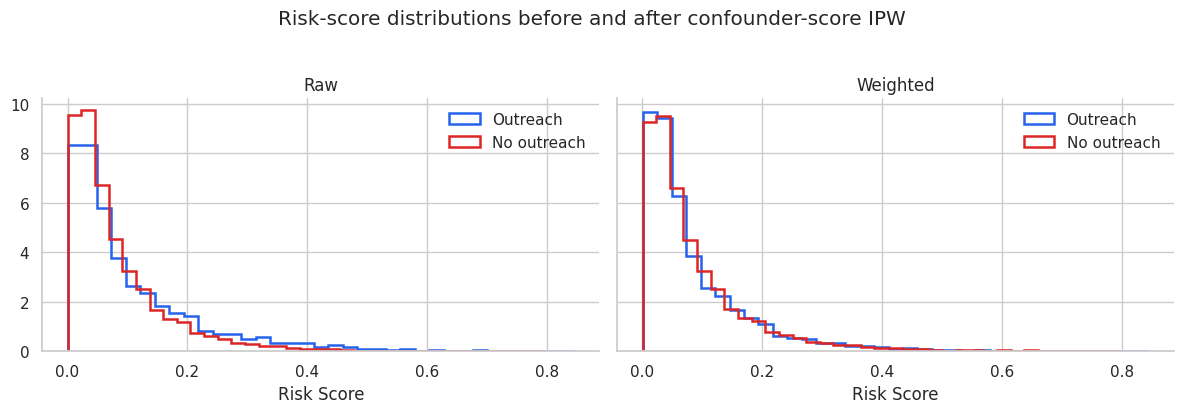

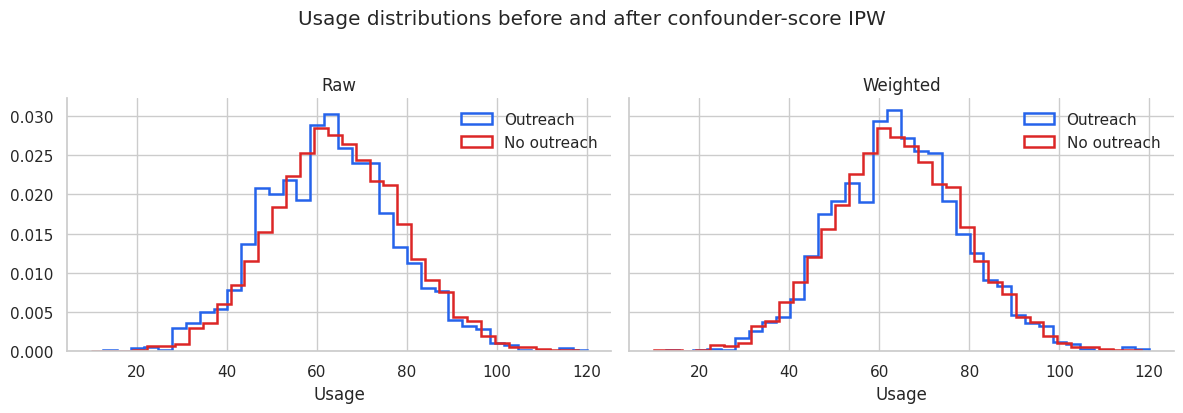

In [14]:
def plot_weighted_histograms(frame, covariate, weights, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, use_weights, subtitle in [
        (axes[0], None, "Raw"),
        (axes[1], weights, "Weighted"),
    ]:
        for treated_value, label, color in [(1, "Outreach", "#2563eb"), (0, "No outreach", "#dc2626")]:
            mask = frame["treated"] == treated_value
            hist_weights = None if use_weights is None else np.asarray(use_weights)[mask]
            ax.hist(
                frame.loc[mask, covariate],
                bins=35,
                weights=hist_weights,
                density=True,
                histtype="step",
                linewidth=1.8,
                color=color,
                label=label,
            )
        ax.set_title(subtitle)
        ax.set_xlabel(covariate.replace("_", " ").title())
        ax.legend(frameon=False)
        sns.despine(ax=ax)
    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.show()

plot_weighted_histograms(
    df,
    covariate="risk_score",
    weights=df["stabilized_ate_weight"],
    title="Risk-score distributions before and after confounder-score IPW",
)

plot_weighted_histograms(
    df,
    covariate="usage",
    weights=df["stabilized_ate_weight"],
    title="Usage distributions before and after confounder-score IPW",
)

### Interpretation

The weighted distributions are much closer than the raw distributions. This is the pseudo-population idea made visual.

Balance plots and weighted distributions answer a design question: after weighting, are we still comparing different kinds of accounts, or did the weights create a more comparable treatment contrast?

## 11. ATT Weights

ATE is not always the business estimand. Sometimes the question is:

> For the accounts we actually contacted, what was the effect of contacting them?

That is the ATT. A common ATT weighting scheme is:

$$
w_i^{ATT} = D_i + (1-D_i)\frac{e(X_i)}{1-e(X_i)}
$$

Treated units keep weight 1. Control units are reweighted to look like the treated population.

,quantity,value
0,True ATT in simulation,4.000
1,Naive treated-control difference,3.024
2,ATT weighted estimate,4.134
3,Bias of ATT weighted estimate,0.135
4,Effective sample size of ATT weights,5196.934
5,Maximum ATT weight,2.109


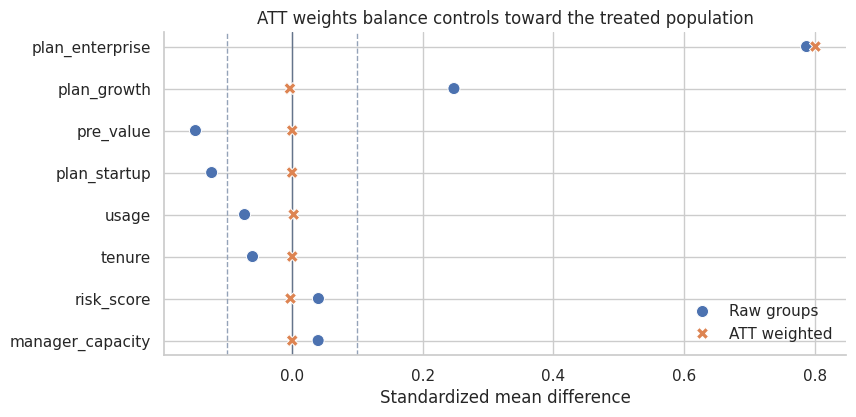

In [15]:
att_weight = att_weights(df["treated"], selected_score)
att_estimate = weighted_difference(df["outcome"], df["treated"], att_weight)
att_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=att_weight)

att_summary = pd.DataFrame({
    "quantity": [
        "True ATT in simulation",
        "Naive treated-control difference",
        "ATT weighted estimate",
        "Bias of ATT weighted estimate",
        "Effective sample size of ATT weights",
        "Maximum ATT weight",
    ],
    "value": [
        true_att,
        naive_effect,
        att_estimate,
        att_estimate - true_att,
        effective_sample_size(att_weight),
        att_weight.max(),
    ],
})

display(att_summary)

plot_smd_comparison(
    {"Raw groups": raw_balance, "ATT weighted": att_balance},
    title="ATT weights balance controls toward the treated population",
)

### Interpretation

ATT weights answer a different question from ATE weights. Instead of making both groups resemble the full population, ATT weights make controls resemble the treated group.

In industry, ATT is often relevant when the intervention already happened and the decision team asks whether the treated accounts benefited. ATE is often relevant when the team asks what would happen if the policy were rolled out broadly to the target population.

## 12. Positivity and Extreme Weights

The most visible IPW failure mode is an extreme weight. Extreme weights occur when a unit receives a treatment status that was very unlikely under the estimated score.

For ATE weights:

| Treatment status | Propensity score | Weight |
|---|---:|---:|
| Treated | close to 0 | very large |
| Treated | close to 1 | close to 1 |
| Control | close to 0 | close to 1 |
| Control | close to 1 | very large |

This is not just a numerical inconvenience. It is a design warning: the data have weak support for the counterfactual comparison in that region.

,propensity_score,treated_weight_1_over_e,control_weight_1_over_1_minus_e
0,0.01,100.000,1.010
1,0.02,50.000,1.020
2,0.05,20.000,1.053
3,0.10,10.000,1.111
4,0.50,2.000,2.000
5,0.90,1.111,10.000
6,0.95,1.053,20.000
7,0.98,1.020,50.000
8,0.99,1.010,100.000


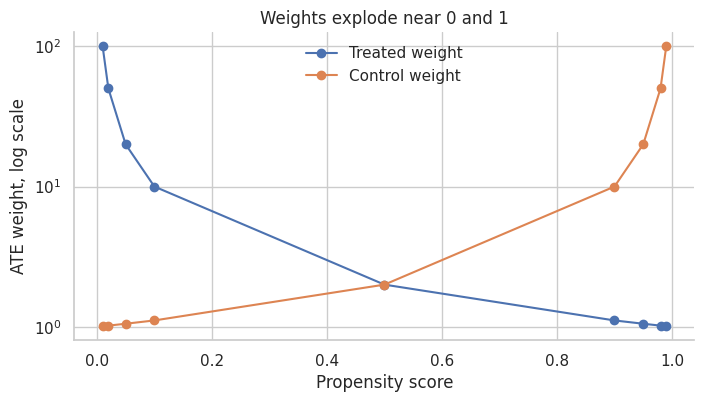

In [16]:
toy_scores = pd.DataFrame({
    "propensity_score": [0.01, 0.02, 0.05, 0.10, 0.50, 0.90, 0.95, 0.98, 0.99],
})
toy_scores["treated_weight_1_over_e"] = 1 / toy_scores["propensity_score"]
toy_scores["control_weight_1_over_1_minus_e"] = 1 / (1 - toy_scores["propensity_score"])
display(toy_scores)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(toy_scores["propensity_score"], toy_scores["treated_weight_1_over_e"], marker="o", label="Treated weight")
ax.plot(toy_scores["propensity_score"], toy_scores["control_weight_1_over_1_minus_e"], marker="o", label="Control weight")
ax.set_yscale("log")
ax.set_xlabel("Propensity score")
ax.set_ylabel("ATE weight, log scale")
ax.set_title("Weights explode near 0 and 1")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

### Interpretation

The log scale is necessary because weights grow so quickly near the boundaries. This is why positivity is not a minor technical assumption. If scores are near 0 or 1, the estimate can depend heavily on a few observations.

The next notebook on covariate balance diagnostics and the later notebook on overlap and trimming will go deeper into diagnosing this problem.

## 13. Weight Capping as a Sensitivity Check

Analysts sometimes cap or trim weights to reduce variance. This can be useful, but it changes the estimator and can introduce bias. It should be reported as a sensitivity analysis, not silently applied.

Here we cap the assignment-heavy stabilized weights at their 99th percentile and compare the result.

,analysis,estimate,effective_sample_size,max_weight,p99_weight,bias_vs_true_ate
0,Assignment-heavy stabilized weights,4.008,7548.197,15.022,2.71,-0.017
1,Same weights capped at p99,3.923,8170.812,2.710,2.71,-0.102


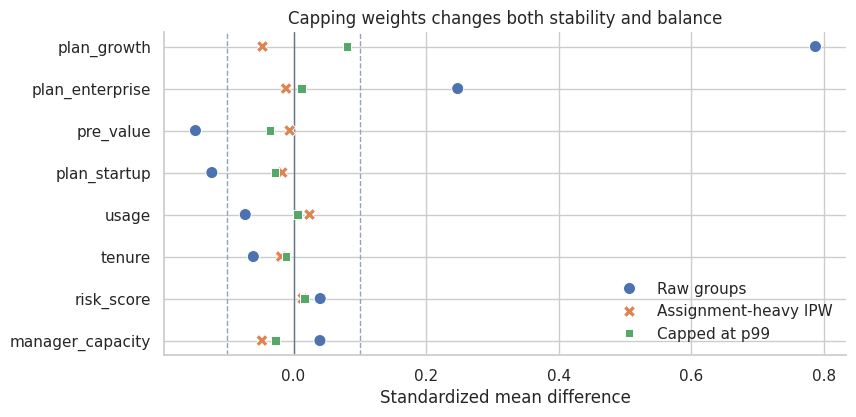

In [17]:
assignment_score = df["Assignment-heavy score"].to_numpy()
assignment_weight = stabilized_ate_weights(df["treated"], assignment_score)
cap_value = np.quantile(assignment_weight, 0.99)
capped_weight = np.minimum(assignment_weight, cap_value)

capping_summary = pd.DataFrame([
    {
        "analysis": "Assignment-heavy stabilized weights",
        "estimate": weighted_difference(df["outcome"], df["treated"], assignment_weight),
        "effective_sample_size": effective_sample_size(assignment_weight),
        "max_weight": assignment_weight.max(),
        "p99_weight": np.quantile(assignment_weight, 0.99),
        "bias_vs_true_ate": weighted_difference(df["outcome"], df["treated"], assignment_weight) - true_ate,
    },
    {
        "analysis": "Same weights capped at p99",
        "estimate": weighted_difference(df["outcome"], df["treated"], capped_weight),
        "effective_sample_size": effective_sample_size(capped_weight),
        "max_weight": capped_weight.max(),
        "p99_weight": np.quantile(capped_weight, 0.99),
        "bias_vs_true_ate": weighted_difference(df["outcome"], df["treated"], capped_weight) - true_ate,
    },
])

display(capping_summary)

assignment_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=assignment_weight)
capped_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=capped_weight)

plot_smd_comparison(
    {
        "Raw groups": raw_balance,
        "Assignment-heavy IPW": assignment_balance,
        "Capped at p99": capped_balance,
    },
    title="Capping weights changes both stability and balance",
)

### Interpretation

Capping improves the weight distribution and effective sample size, but it can also change covariate balance and the estimated effect. There is no free lunch.

In a professional report, capping should be justified with diagnostics and shown as part of a sensitivity analysis. If conclusions require aggressive capping, the data may not support the original ATE target well.

## 14. IPW Versus Regression Adjustment

Outcome regression and IPW use different models:

- Regression adjustment models `E[Y | D, X]`.
- IPW models `P(D = 1 | X)`.

If the propensity model is correct and the assumptions hold, IPW can estimate a marginal causal effect without specifying the outcome regression. If the propensity model is wrong, IPW can be biased.

This motivates doubly robust methods, which combine outcome modeling and weighting. We will return to that later in this module.

In [18]:
outcome_model = smf.ols(
    "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    data=df,
).fit(cov_type="HC3")

comparison_table = pd.DataFrame({
    "method": [
        "Naive difference",
        "Outcome regression adjustment",
        "IPW Hájek - confounder score",
        "IPW Hájek - underspecified score",
        "IPW Hájek - assignment-heavy score",
    ],
    "estimate": [
        naive_effect,
        outcome_model.params["treated"],
        estimate_table.loc[estimate_table["analysis"] == "Confounder score", "hajek_or_weighted_difference"].iloc[0],
        estimate_table.loc[estimate_table["analysis"] == "Underspecified score", "hajek_or_weighted_difference"].iloc[0],
        estimate_table.loc[estimate_table["analysis"] == "Assignment-heavy score", "hajek_or_weighted_difference"].iloc[0],
    ],
})
comparison_table["true_ate"] = true_ate
comparison_table["bias_vs_true_ate"] = comparison_table["estimate"] - true_ate
display(comparison_table)

,method,estimate,true_ate,bias_vs_true_ate
0,Naive difference,3.024,4.025,-1.001
1,Outcome regression adjustment,4.140,4.025,0.116
2,IPW Hájek - confounder score,4.168,4.025,0.143
3,IPW Hájek - underspecified score,3.472,4.025,-0.553
4,IPW Hájek - assignment-heavy score,4.008,4.025,-0.017


### Interpretation

The adjusted outcome regression and the well-specified IPW estimate both move toward the true ATE. They get there through different modeling assumptions.

This comparison is useful in practice. If outcome regression and IPW tell very different stories, you should inspect the adjustment set, overlap, functional forms, and influential observations before making a business recommendation.

## 15. Industry Readout Checklist

An IPW readout should include more than the final estimate.

| Step | Question | What to show |
|---|---|---|
| 1. Estimand | ATE, ATT, or another target population? | One-sentence causal question. |
| 2. Assignment model | What predicts treatment before the outcome? | Propensity-score formula or model card. |
| 3. Assumptions | Why is no unmeasured confounding plausible? | Timing, DAG, domain argument. |
| 4. Positivity | Are scores close to 0 or 1? | Score distribution by treatment group. |
| 5. Weights | Are weights stable? | Weight percentiles, max, ESS. |
| 6. Balance | Did weighting balance covariates? | SMD table and plot. |
| 7. Estimate | What is the causal effect and uncertainty? | Weighted mean or marginal model result. |
| 8. Sensitivity | Do results change with model choice or capping? | Specification and trimming table. |
| 9. Limitations | What could still bias the result? | Hidden confounding, measurement error, interference. |

If the report contains only the final weighted coefficient, it is not yet a causal readout.

## Key Takeaways

- IPW reweights the data to create a pseudo-population where treatment is balanced on observed covariates.
- ATE weights are `1 / e(X)` for treated units and `1 / (1 - e(X))` for controls.
- Stabilized weights make diagnostics easier and often improve finite-sample behavior.
- Hájek, or normalized, IPW estimates are often more stable than unnormalized Horvitz-Thompson estimates in finite samples.
- Weight diagnostics are central: extreme weights, low ESS, and poor balance are design warnings.
- High treatment-prediction AUC is not automatically a good causal design.
- Trimming or capping weights can reduce variance but changes the analysis and must be reported.
- IPW does not solve hidden confounding. It balances observed covariates only.

## References

Austin, P. C. (2011). An introduction to propensity score methods for reducing the effects of confounding in observational studies. *Multivariate Behavioral Research, 46*(3), 399-424. https://doi.org/10.1080/00273171.2011.568786

Cole, S. R., & Hernán, M. A. (2008). Constructing inverse probability weights for marginal structural models. *American Journal of Epidemiology, 168*(6), 656-664. https://doi.org/10.1093/aje/kwn164

Horvitz, D. G., & Thompson, D. J. (1952). A generalization of sampling without replacement from a finite universe. *Journal of the American Statistical Association, 47*(260), 663-685. https://doi.org/10.1080/01621459.1952.10483446

Li, F., Morgan, K. L., & Zaslavsky, A. M. (2017). Balancing covariates via propensity score weighting. *Journal of the American Statistical Association, 113*(521), 390-400. https://doi.org/10.1080/01621459.2016.1260466

Lunceford, J. K., & Davidian, M. (2004). Stratification and weighting via the propensity score in estimation of causal treatment effects: A comparative study. *Statistics in Medicine, 23*(19), 2937-2960. https://doi.org/10.1002/sim.1903

Robins, J. M., Hernán, M. A., & Brumback, B. (2000). Marginal structural models and causal inference in epidemiology. *Epidemiology, 11*(5), 550-560. https://doi.org/10.1097/00001648-200009000-00011

Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41